# Dumbbell Chart

This section showcases the dumbbell chart. It contains examples of how to create dumbbell charts using the [datachart.charts.DumbbellChart](../../../references/charts/#datachart.charts.DumbbellChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-dumbbell-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the dumbbell charts are created using the `DumbbellChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import DumbbellChart

## Dumbbell Chart Input Attributes

The `DumbbellChart` function accepts keyword arguments for chart configuration. The main argument is `data`, a list of records. Each record names its category in `label` and its two endpoints, `start` and `end`, as finite numbers; it may add its own `emphasis`. A list of such lists overlays several charts on the same categories, or draws one per subplot with `subplots=True`.

```python
DumbbellChart(
    data=[                                               # The records (or list of lists for multiple charts)
        {
            "label": str,                                # The category, unique within the chart; its row label
            "start": Union[int, float],                  # The value of the start endpoint
            "end": Union[int, float],                    # The value of the end endpoint
            "emphasis": Optional[EMPHASIS],              # The record's own emphasis role ("background", "highlight")
        },
    ],
    style={                                              # The style of the chart (optional)
        "plot_dumbbell_start_color":     Optional[str],  # The start dot color; None takes the PaperAccent blue
        "plot_dumbbell_end_color":       Optional[str],  # The end dot color; None takes the PaperAccent red
        "plot_dumbbell_alpha":           Optional[float],# The alpha of the dots
        "plot_dumbbell_size":            Optional[float],# The dot size, in points squared
        "plot_dumbbell_start_marker":    Optional[LINE_MARKER], # The marker of the start dots
        "plot_dumbbell_end_marker":      Optional[LINE_MARKER], # The marker of the end dots
        "plot_dumbbell_edge_width":      Optional[float],# The edge width of the dots
        "plot_dumbbell_edge_color":      Optional[str],  # The edge color of the dots
        "plot_dumbbell_zorder":          Optional[float],# The zorder of the dots
        "plot_dumbbell_connector_color": Optional[str],  # The color of the connectors
        "plot_dumbbell_connector_width": Optional[float],# The line width of the connectors
        "plot_dumbbell_connector_style": Optional[LINE_STYLE], # The line style of the connectors
        "plot_dumbbell_connector_zorder": Optional[float], # The zorder of the connectors, below the dots
        "plot_dumbbell_arrow_color":     Optional[str],  # The color of the direction arrows
        "plot_dumbbell_arrow_width":     Optional[float],# The line width of the direction arrows
        "plot_dumbbell_arrow_style":     Optional[str],  # The direction arrow head, as a matplotlib arrow style
        "plot_dumbbell_arrow_gap":       Optional[float],# The space between a dot and its direction arrow, in points
        "plot_dumbbell_grid_minor":      Optional[int],  # The parts each value step splits into with fainter gridlines (0 for none)
    },
    subtitle=Optional[str],                              # The subtitle (or list for multiple charts)
    title=Optional[str],                                 # The title of the chart
    xlabel=Optional[str],                                # The label of the horizontal axis
    ylabel=Optional[str],                                # The label of the vertical axis
    figsize=Optional[Tuple[float, float]],               # The figure size in inches
    xmin=Optional[float], xmax=Optional[float],          # The horizontal axis limits
    ymin=Optional[float], ymax=Optional[float],          # The vertical axis limits
    orientation=Optional[ORIENTATION],                   # Which way the values run ("horizontal" by default, "vertical")
    scaley=Optional[SCALE],                              # The scale of the value axis
    xtickrotate=Optional[int],                           # The rotation of the horizontal tick labels
    ytickrotate=Optional[int],                           # The rotation of the vertical tick labels

    start_name=Optional[str],                            # The name of the start endpoint, in the legend
    end_name=Optional[str],                              # The name of the end endpoint, in the legend
    show_legend=Optional[bool],                          # Whether to show the legend (on when a name is given)
    legend=Optional[LegendSettingAttrs],                 # The legend title, location, and columns
    show_grid=Optional[SHOW_GRID],                       # Which grid lines to show ("both", "x", "y"); the value axis by default
    show_values=Optional[DUMBBELL_VALUE],                # The value labels ("endpoints", "delta")
    show_direction=Optional[bool],                       # Whether to draw a thin start-to-end arrow beside each connector
    value_format=Optional[str],                          # The format of the value labels

    sort=Optional[SORT],                                 # The category order (None, "ascending", "descending")
    sort_by=Optional[DUMBBELL_SORT_KEY],                 # What the categories sort by ("start", "end", "delta")
    marker=Optional[Tuple[LINE_MARKER, LINE_MARKER]],    # The (start, end) marker pair
    connector_style=Optional[LINE_STYLE],                # The line style of the connectors

    emphasis=Optional[EMPHASIS],                         # The emphasis role of the whole chart (or list per chart)
    emphasis_rule=Optional[EmphasisRuleAttrs],           # Highlight the records matching a rule on their delta

    subplots=Optional[bool],                             # Whether to draw each chart in its own subplot
    max_cols=Optional[int],                              # Maximum number of subplots per row
    sharex=Optional[bool], sharey=Optional[bool],        # Whether the subplots share their axes

    vlines=Optional[List[VLineSettingAttrs]],            # Vertical lines
    hlines=Optional[List[HLineSettingAttrs]],            # Horizontal lines
    vspans=Optional[List[VSpanSettingAttrs]],            # Vertical bands
    hspans=Optional[List[HSpanSettingAttrs]],            # Horizontal bands
    texts=Optional[List[TextSettingAttrs]],              # Text annotations
)
```

For more details, see the [datachart.charts.DumbbellChart](../../../references/charts/#datachart.charts.DumbbellChart) function.

## Basics

The examples in this guide share one dataset: life expectancy at birth in twelve countries in 2000 and in 2019, the last year before the COVID-19 pandemic, from the [World Health Organization's Global Health Observatory](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/life-expectancy-at-birth-(years)), rounded to one decimal. `life` holds one record per country for both sexes together; `women` and `men` hold the same records per sex. `recent` runs from 2019 to 2021, across the COVID-19 pandemic, when life expectancy fell in most of these countries and rose in a few.

In [2]:
# life expectancy at birth in years, 2000 and 2019 (WHO Global Health Observatory)
LIFE = {
    # country: (both sexes 2000, 2019), (women 2000, 2019), (men 2000, 2019)
    "Japan": ((81.5, 84.5), (84.8, 87.2), (78.1, 81.7)),
    "Switzerland": ((79.7, 83.5), (82.3, 85.1), (76.9, 81.8)),
    "Norway": ((78.5, 82.7), (81.2, 84.2), (75.9, 81.1)),
    "Slovenia": ((76.1, 81.3), (79.7, 84.0), (72.2, 78.6)),
    "Germany": ((78.1, 81.0), (80.9, 83.2), (75.0, 78.7)),
    "United States": ((76.7, 78.7), (79.1, 81.0), (74.2, 76.5)),
    "China": ((70.8, 77.3), (73.3, 80.4), (68.6, 74.6)),
    "Brazil": ((71.5, 75.5), (75.0, 78.7), (68.2, 72.2)),
    "Russia": ((65.2, 73.2), (72.1, 78.0), (58.8, 68.2)),
    "India": ((63.2, 70.7), (64.3, 72.4), (62.2, 69.2)),
    "South Africa": ((57.1, 65.8), (59.6, 68.8), (54.2, 62.5)),
    "Nigeria": ((54.1, 63.1), (55.4, 64.5), (52.8, 61.7)),
}


def records(column):
    return [
        {"label": country, "start": values[column][0], "end": values[column][1]}
        for country, values in LIFE.items()
    ]


life, women, men = records(0), records(1), records(2)

# both sexes, 2019 and 2021 (WHO Global Health Observatory)
RECENT = {
    "Japan": (84.5, 84.5),
    "Switzerland": (83.5, 83.3),
    "Norway": (82.7, 82.9),
    "Slovenia": (81.3, 80.4),
    "Germany": (81.0, 80.5),
    "United States": (78.7, 76.4),
    "China": (77.3, 77.6),
    "Brazil": (75.5, 72.4),
    "Russia": (73.2, 70.0),
    "India": (70.7, 67.3),
    "South Africa": (65.8, 61.5),
    "Nigeria": (63.1, 63.4),
}
recent = [{"label": c, "start": s, "end": e} for c, (s, e) in RECENT.items()]

The data is a list of dictionaries, one per country: `label` names the category, `start` holds the value in 2000, and `end` the value in 2019.

In [3]:
life[0]

{'label': 'Japan', 'start': 81.5, 'end': 84.5}

**Basic example.** Only the `data` argument is required to draw the dumbbell chart. Every record is one row: a blue dot at its start, a red dot at its end, and a grey connector between them, the first record at the top. The dots take the two colors of the `PaperAccent` palette unless the theme or the style sets its own pair, and the gridlines run along the values.

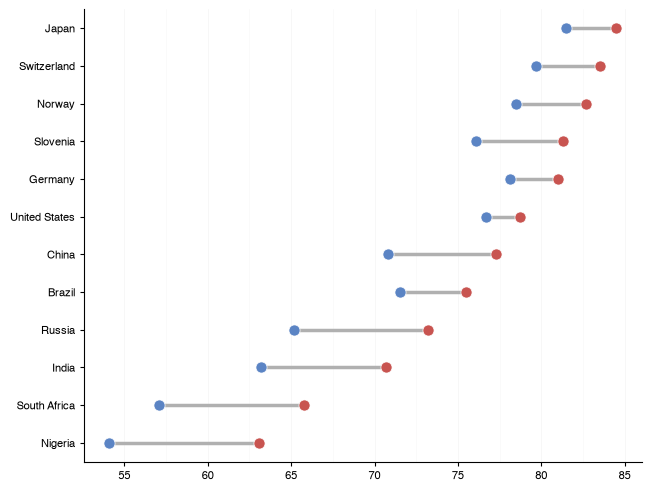

In [4]:
DumbbellChart(
    # add the data to the chart
    data=life
).show()

## Customizing the Dumbbell Chart

Every customization is either a keyword argument of `DumbbellChart` or a `plot_dumbbell_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                     | Use                                                          | See |
| :--------------------------------------------- | :----------------------------------------------------------- | :-- |
| add a title or axis labels                     | `title`, `xlabel`, `ylabel`                                  | [Title, labels, and figure size](#title-labels-and-figure-size) |
| resize the figure                              | `figsize`                                                    | [Title, labels, and figure size](#title-labels-and-figure-size) |
| change the gridlines                           | `show_grid`                                                  | [Orientation](#orientation) |
| draw the values up the page instead of across  | `orientation`                                                | [Orientation](#orientation) |
| order the categories by start, end, or change  | `sort`, `sort_by`                                            | [Category order](#category-order) |
| name the two endpoints in a legend             | `start_name`, `end_name`, `legend`                           | [Endpoint names and legend](#endpoint-names-and-legend) |
| print the endpoint values or the change        | `show_values`, `value_format`                                | [Value labels](#value-labels) |
| show whether each value rose or fell           | `show_direction`                                             | [Rises and falls](#rises-and-falls) |
| tell the endpoints apart by shape              | `marker`                                                     | [Markers and connectors](#markers-and-connectors) |
| dash the connectors                            | `connector_style`                                            | [Markers and connectors](#markers-and-connectors) |
| change the dot and connector colors and sizes  | `style={"plot_dumbbell_start_color": ..., ...}`            | [Dumbbell style](#dumbbell-style) |
| highlight some categories, mute the rest       | `emphasis` record key, `emphasis_rule`, `emphasis`           | [Emphasis](#emphasis) |
| mark a reference value                         | `vlines`, `vspans`, `hlines`, `hspans`                       | [Reference lines](#reference-lines) |
| compare several groups on the same categories  | `data` as a list of lists, `subtitle`                        | [Overlaid charts](#overlaid-charts) |
| draw each group in its own subplot             | `subplots`, `max_cols`, `sharex`                             | [Subplots](#subplots) |
| combine with other charts                      | `Panel`, `Grid`                                              | [Composing dumbbell charts](#composing-dumbbell-charts) |
| save the chart to a file                       | `save_figure`                                                | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.DumbbellStyleAttrs](../../../references/typings/#datachart.typings.DumbbellStyleAttrs) type; the full list of parameters is in the [datachart.charts.DumbbellChart](../../../references/charts/#datachart.charts.DumbbellChart) reference.

### Title, labels, and figure size

To add the chart title and the axis labels, add the `title`, `xlabel`, and `ylabel` attributes. The axis attributes are spatial: in the default horizontal chart, `xlabel` names the value axis and `ylabel` the category axis.

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains some of the predefined figure sizes.

In [5]:
from datachart.constants import FIG_SIZE

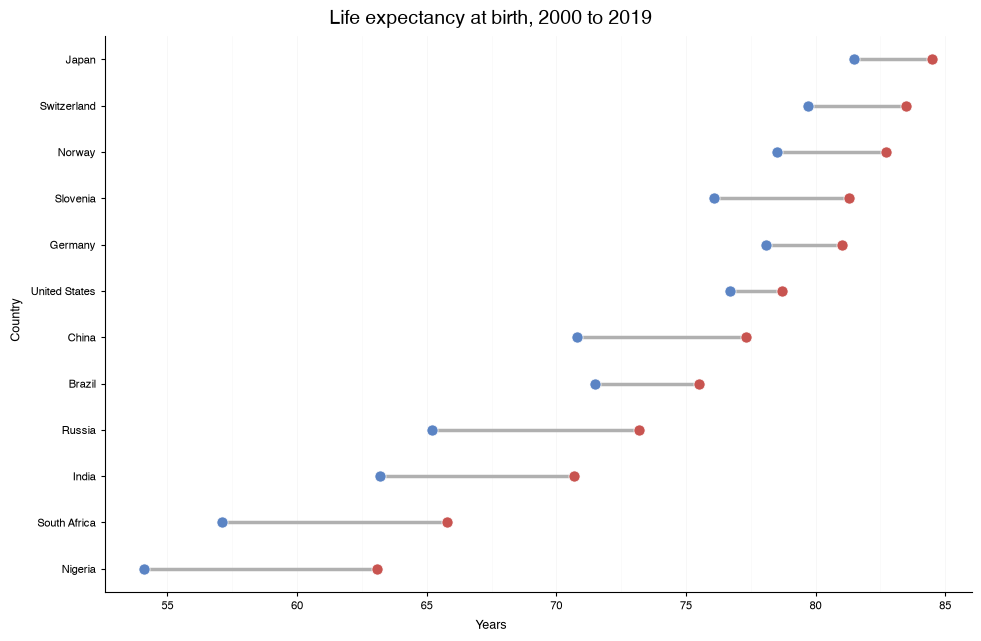

In [6]:
DumbbellChart(
    data=life,
    # add the title and the axis labels
    title="Life expectancy at birth, 2000 to 2019",
    xlabel="Years",
    ylabel="Country",
    # add to determine the figure size
    figsize=FIG_SIZE.A4_LANDSCAPE,
).show()

### Orientation

The values run along the horizontal axis by default, one row per category. To run them up the page, one column per category, add the `orientation` attribute with a [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) constant. The first category sits at the left; `xtickrotate` turns long category names.

The gridlines follow the values: vertical lines in a horizontal chart, horizontal lines in a vertical one, with a fainter line halfway between each pair of labelled values so a dot's value reads off quickly. The `plot_dumbbell_grid_minor` style attribute sets how many parts each step splits into (0 draws no fainter lines). An explicit `show_grid`, a [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant, picks the axes literally.

In [7]:
from datachart.constants import ORIENTATION

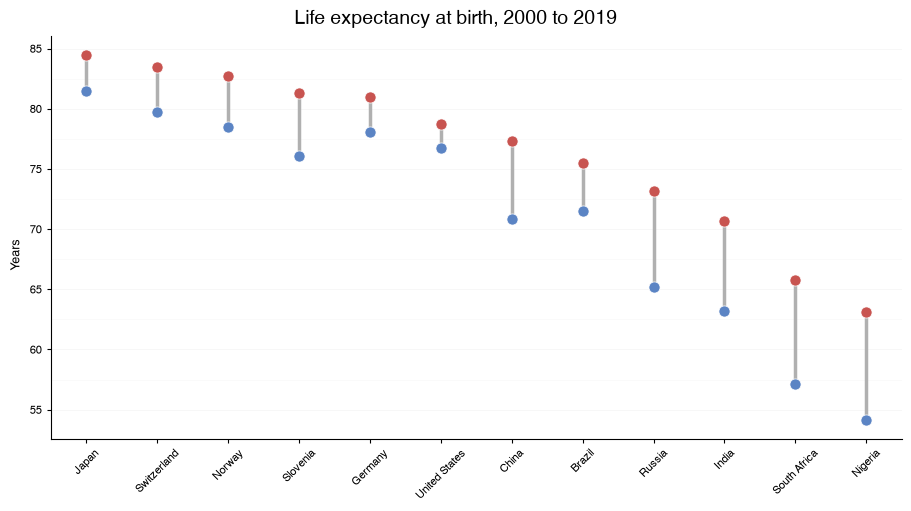

In [8]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth, 2000 to 2019",
    ylabel="Years",
    # run the values up the page
    orientation=ORIENTATION.VERTICAL,
    xtickrotate=45,
    figsize=(9, 5),
).show()

### Category order

The categories follow the input order by default. To order them, add the `sort` attribute with a [datachart.constants.SORT](../../../references/constants/#datachart.constants.SORT) constant; the `sort_by` attribute, a [datachart.constants.DUMBBELL_SORT_KEY](../../../references/constants/#datachart.constants.DUMBBELL_SORT_KEY) constant, names what they sort by: `START` (the default), `END`, or `DELTA`, the change `end - start`. Ties keep the input order; `sort_by` without `sort` raises a `ValueError`.

In [9]:
from datachart.constants import SORT, DUMBBELL_SORT_KEY

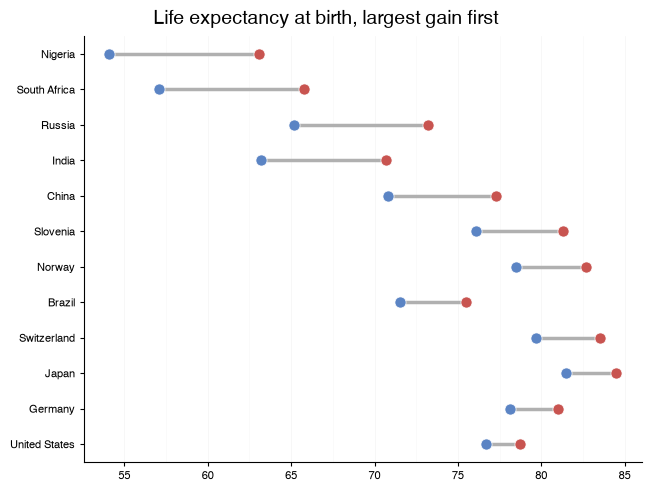

In [10]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth, largest gain first",
    # order the countries by their change, the largest first
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
).show()

### Endpoint names and legend

The two endpoints are named by the `start_name` and `end_name` attributes; each named endpoint gets one legend entry, and the legend is on as soon as a name is given. To hide it, set `show_legend=False`; to give it a title or move it, add the `legend` attribute, a [datachart.typings.LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs) dictionary.

In [11]:
from datachart.constants import LEGEND_LOCATION

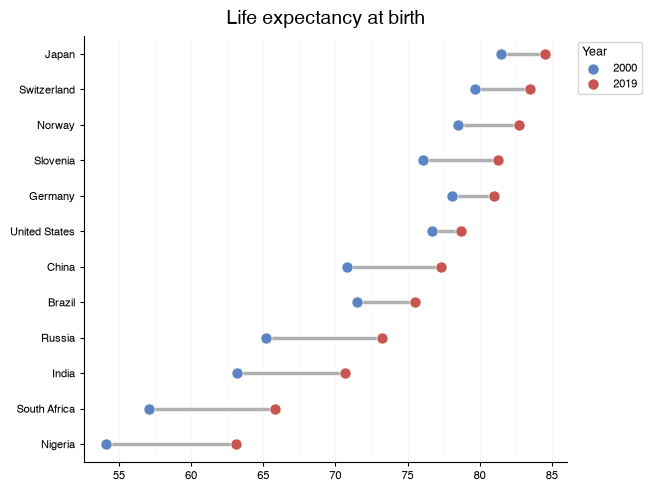

In [12]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    # name the endpoints
    start_name="2000",
    end_name="2019",
    # title the legend and place it beside the chart
    legend={"title": "Year", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Value labels

To print the values, add the `show_values` attribute with a [datachart.constants.DUMBBELL_VALUE](../../../references/constants/#datachart.constants.DUMBBELL_VALUE) constant: `ENDPOINTS` prints each endpoint's value past its dot, on the side away from the connector; `DELTA` prints the change `end - start` at the connector midpoint. A record whose endpoints coincide draws a single dot, no connector, and a delta of zero. The `value_format` attribute formats the numbers — use a [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"` style string; `"{:+.1f}"` signs the delta.

In [13]:
from datachart.constants import DUMBBELL_VALUE

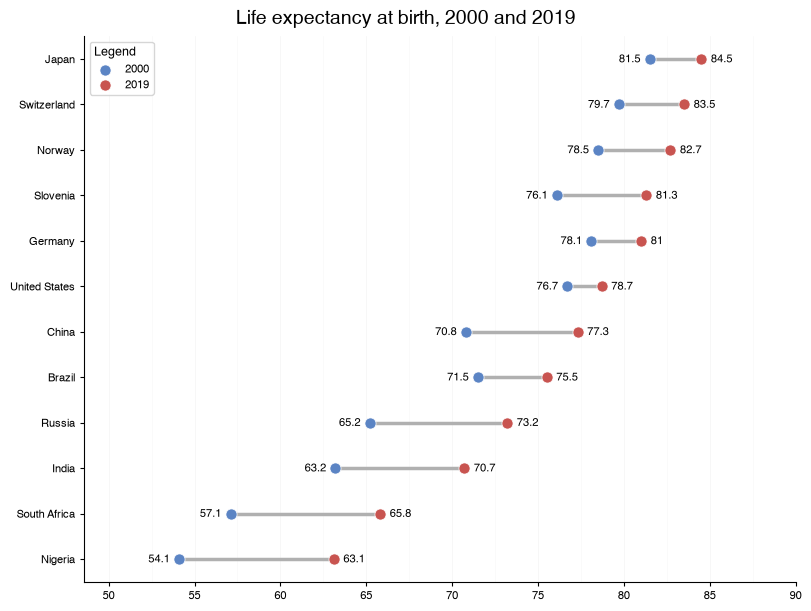

In [14]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth, 2000 and 2019",
    start_name="2000",
    end_name="2019",
    # print both endpoint values
    show_values=DUMBBELL_VALUE.ENDPOINTS,
    figsize=(8, 6),
).show()

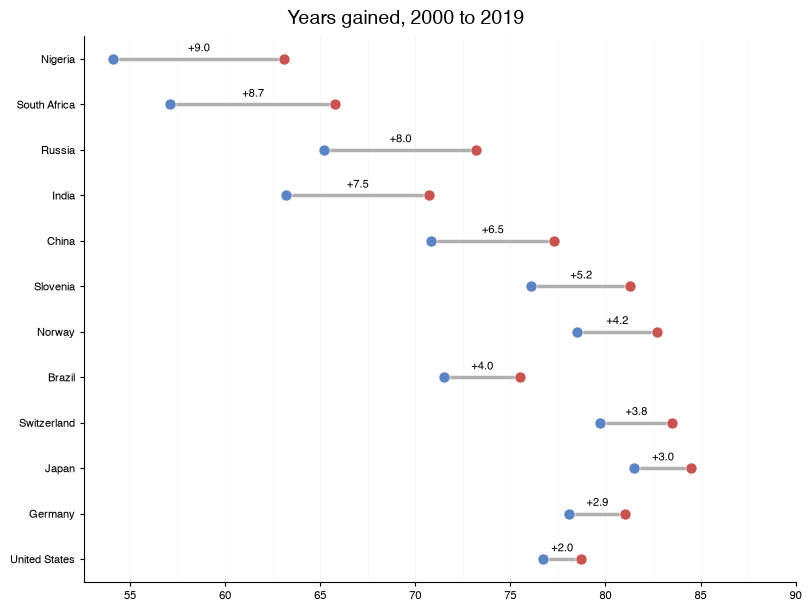

In [15]:
DumbbellChart(
    data=life,
    title="Years gained, 2000 to 2019",
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
    # print the signed change at every connector
    show_values=DUMBBELL_VALUE.DELTA,
    value_format="{:+.1f}",
    figsize=(8, 6),
).show()

### Rises and falls

The end dot can sit on either side of the start dot: a value that fell has its end dot left of (or below) its start dot. From 2019 to 2021 life expectancy fell in most of these countries, rose slightly in Norway, China, and Nigeria, and held in Japan, whose record draws a single dot. Color alone tells the two endpoints apart; to show the direction at a glance, add `show_direction=True`. A thin arrow runs beside each connector from the start to the end — above a horizontal dumbbell, right of a vertical one — and a delta label moves out past it. The `plot_dumbbell_arrow_*` style attributes set its look.

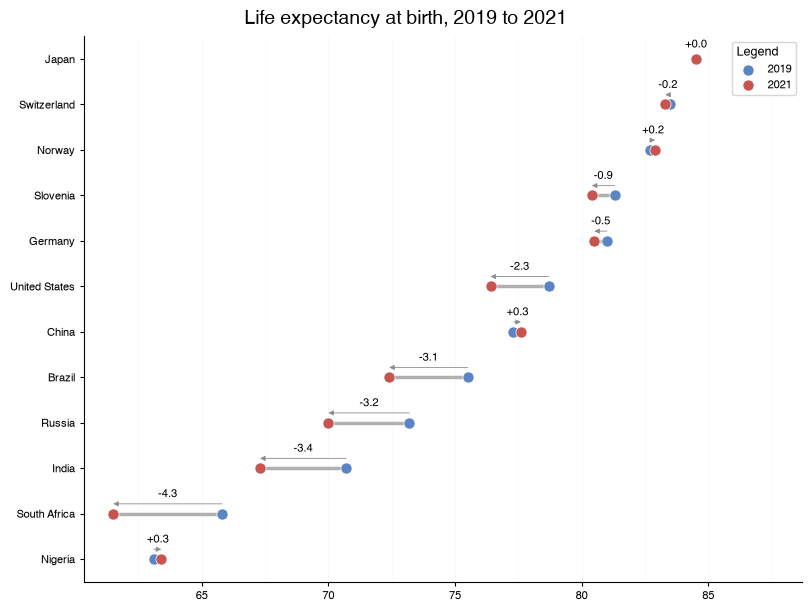

In [16]:
DumbbellChart(
    data=recent,
    title="Life expectancy at birth, 2019 to 2021",
    start_name="2019",
    end_name="2021",
    # an arrow beside every connector, from start to end
    show_direction=True,
    show_values=DUMBBELL_VALUE.DELTA,
    value_format="{:+.1f}",
    figsize=(8, 6),
).show()

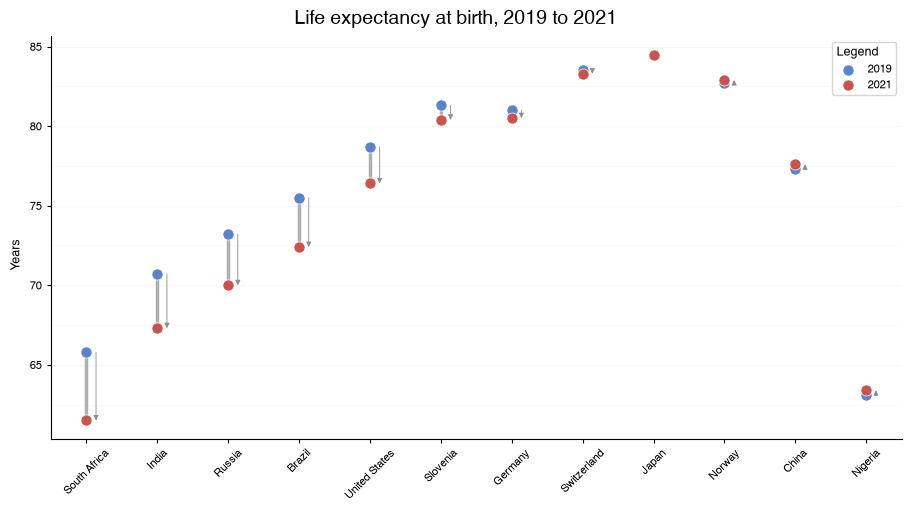

In [17]:
DumbbellChart(
    data=recent,
    title="Life expectancy at birth, 2019 to 2021",
    ylabel="Years",
    start_name="2019",
    end_name="2021",
    # the arrows follow the values up the page
    orientation=ORIENTATION.VERTICAL,
    xtickrotate=45,
    show_direction=True,
    sort=SORT.ASCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
    figsize=(9, 5),
).show()

### Markers and connectors

To tell the endpoints apart by shape as well as color — for print in greyscale, say — add the `marker` attribute, a `(start, end)` pair of [datachart.constants.LINE_MARKER](../../../references/constants/#datachart.constants.LINE_MARKER) values. The `connector_style` attribute sets the line style of the connectors with a [datachart.constants.LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE) constant. Both replace the theme's choice; a chart's `style` dictionary still wins over them.

In [18]:
from datachart.constants import LINE_MARKER, LINE_STYLE

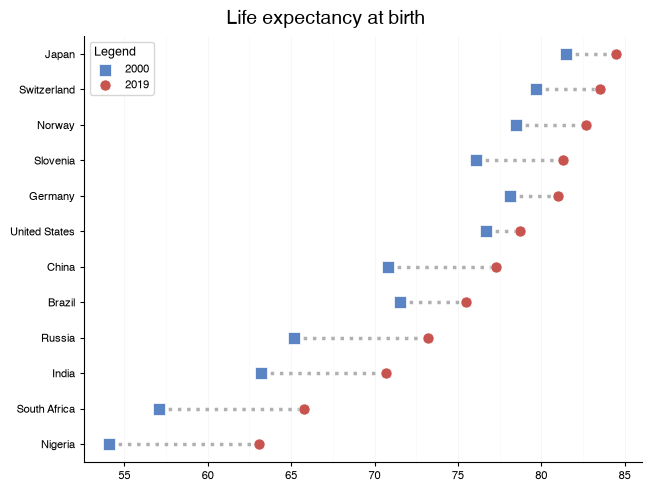

In [19]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    start_name="2000",
    end_name="2019",
    # a square for the start, a circle for the end
    marker=(LINE_MARKER.SQUARE, LINE_MARKER.CIRCLE),
    # dotted connectors
    connector_style=LINE_STYLE.DOTTED,
).show()

### Dumbbell style

To change the style, add the `style` attribute with the corresponding attributes; they are shown in the [datachart.typings.DumbbellStyleAttrs](../../../references/typings/#datachart.typings.DumbbellStyleAttrs) type. The value labels take the shared `plot_value_*` attributes.

| Attribute                         | Description |
| :-------------------------------- | :---------- |
| `plot_dumbbell_start_color`       | The color of the start dots; `None` takes the first color of the `PaperAccent` pair. |
| `plot_dumbbell_end_color`         | The color of the end dots; `None` takes the second color of the `PaperAccent` pair. |
| `plot_dumbbell_alpha`             | The alpha (transparency) of the dots. |
| `plot_dumbbell_size`              | The size of the dots, in points squared. |
| `plot_dumbbell_start_marker`      | The marker of the start dots. |
| `plot_dumbbell_end_marker`        | The marker of the end dots. |
| `plot_dumbbell_edge_width`        | The edge width of the dots. |
| `plot_dumbbell_edge_color`        | The edge color of the dots. |
| `plot_dumbbell_zorder`            | The zorder of the dots. |
| `plot_dumbbell_connector_color`   | The color of the connectors. |
| `plot_dumbbell_connector_width`   | The line width of the connectors. |
| `plot_dumbbell_connector_style`   | The line style of the connectors. |
| `plot_dumbbell_connector_zorder`  | The zorder of the connectors; below the dots by default. |
| `plot_dumbbell_arrow_color`       | The color of the direction arrows under `show_direction`. |
| `plot_dumbbell_arrow_width`       | The line width of the direction arrows. |
| `plot_dumbbell_arrow_style`       | The direction arrow head, as a matplotlib arrow style. |
| `plot_dumbbell_arrow_gap`         | The space between a dot's edge and its direction arrow, in points. |
| `plot_dumbbell_grid_minor`        | The parts each step between labelled values splits into with fainter gridlines; 0 draws none. |

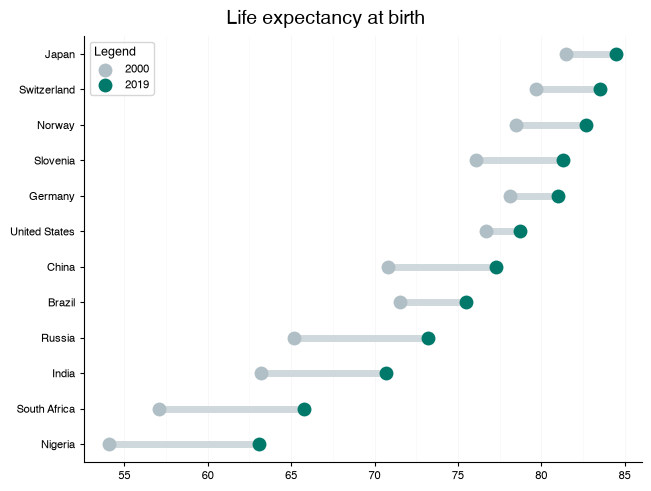

In [20]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    start_name="2000",
    end_name="2019",
    # define the style of the chart
    style={
        "plot_dumbbell_start_color": "#B0BEC5",
        "plot_dumbbell_end_color": "#00796B",
        "plot_dumbbell_size": 100,
        "plot_dumbbell_edge_width": 0,
        "plot_dumbbell_connector_color": "#CFD8DC",
        "plot_dumbbell_connector_width": 5,
    },
).show()

### Emphasis

A record's own `emphasis` key takes a [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) role: `"highlight"` rims the dots in the text color and thickens the connector, `"background"` mutes the dots and the connector in the theme's muted color and drops their labels. The `emphasis_rule` attribute sets the roles by a rule on each record's change `end - start` — `{"above": v}`, `{"below": v}`, `{"between": (lo, hi)}`, `{"top": n}`, or `{"bottom": n}` — highlighting the records that match and muting the rest; a record's own key wins over the rule. The `emphasis` attribute sets one role for a whole chart. See the [highlighting guide](../../styling/highlighting.ipynb) for emphasis across the charts.

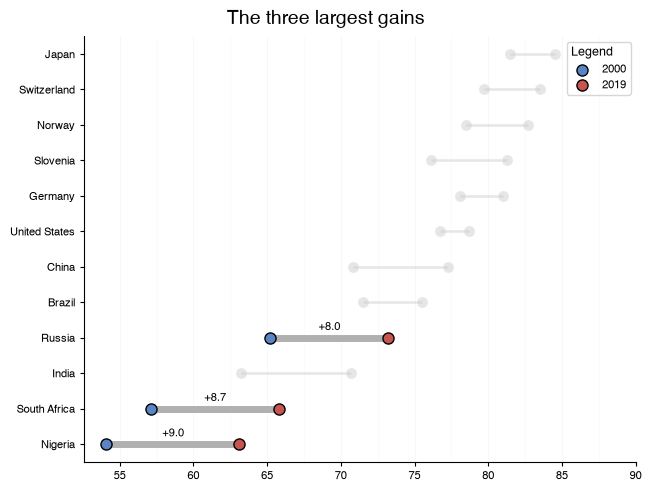

In [21]:
DumbbellChart(
    data=life,
    title="The three largest gains",
    start_name="2000",
    end_name="2019",
    # highlight the three largest changes, mute the rest
    emphasis_rule={"top": 3},
    show_values=DUMBBELL_VALUE.DELTA,
    value_format="{:+.1f}",
).show()

### Reference lines

The `vlines`, `hlines`, `vspans`, and `hspans` attributes draw reference lines and bands, such as the world average; see the [datachart.typings.VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs) and [datachart.typings.VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) types. In the default horizontal chart a value is marked with a vertical line.

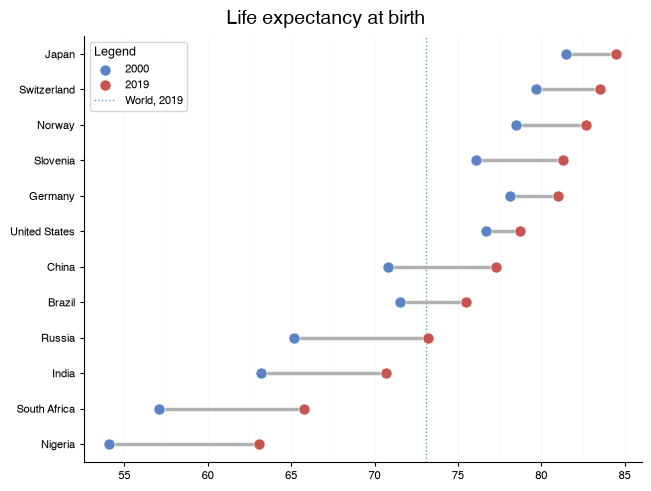

In [22]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    start_name="2000",
    end_name="2019",
    # the global life expectancy at birth in 2019 (WHO)
    vlines={"x": 73.1, "label": "World, 2019", "style": {"plot_vline_style": ":"}},
).show()

## Multiple Dumbbell Charts

### Overlaid charts

To compare groups on the same categories, pass a list of lists to the `data` argument. The charts share one category axis — a category any chart lists gets a row — and overlay at its center, each in its own palette color: the end dot in the color, the start dot in a lighter shade. With `subtitle` and the endpoint names, the legend reads *subtitle (name)* per endpoint.

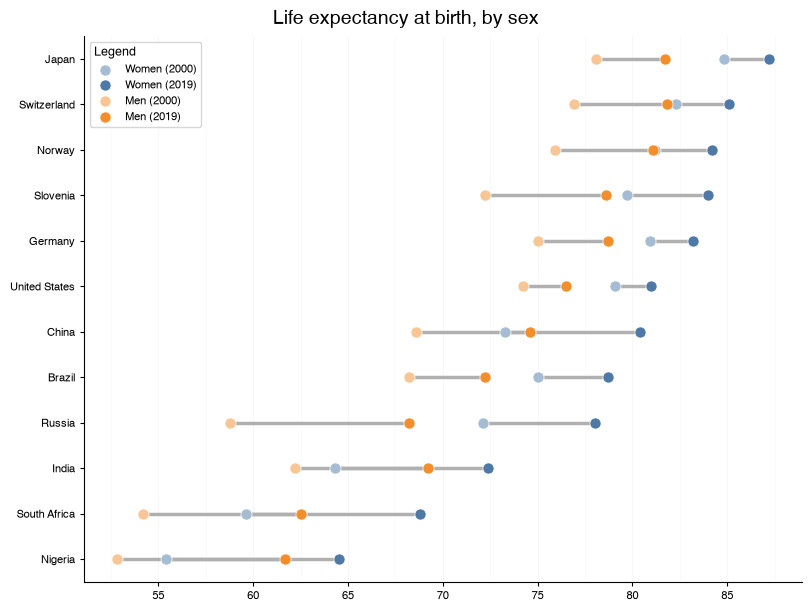

In [23]:
DumbbellChart(
    # use a list of lists to overlay charts on the same categories
    data=[women, men],
    subtitle=["Women", "Men"],
    start_name="2000",
    end_name="2019",
    title="Life expectancy at birth, by sex",
    figsize=(8, 6),
).show()

### Subplots

To draw each chart in its own subplot instead, add `subplots=True`; `max_cols` sets the subplots per row and `sharex` puts them on one value scale. Per-chart attributes like `subtitle` and `style` can be lists. The legend is off in subplots.

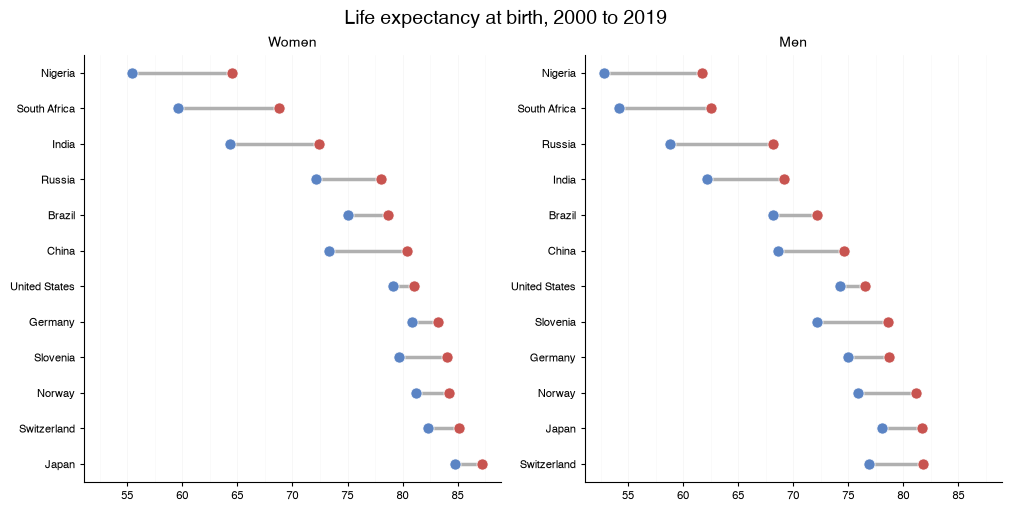

In [24]:
DumbbellChart(
    data=[women, men],
    subtitle=["Women", "Men"],
    title="Life expectancy at birth, 2000 to 2019",
    # one subplot per chart, on one value scale
    subplots=True,
    sharex=True,
    sort=SORT.ASCENDING,
    sort_by=DUMBBELL_SORT_KEY.END,
    figsize=(10, 5),
).show()

### Composing dumbbell charts

A dumbbell chart places its rows on the category axis the box, violin, and swarm plots share, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays it with them and with other dumbbell charts, and [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it beside any chart. Bars place their categories differently, so a dumbbell chart does not overlay a bar chart. The example sets the gap between women and men beside the change for both sexes.

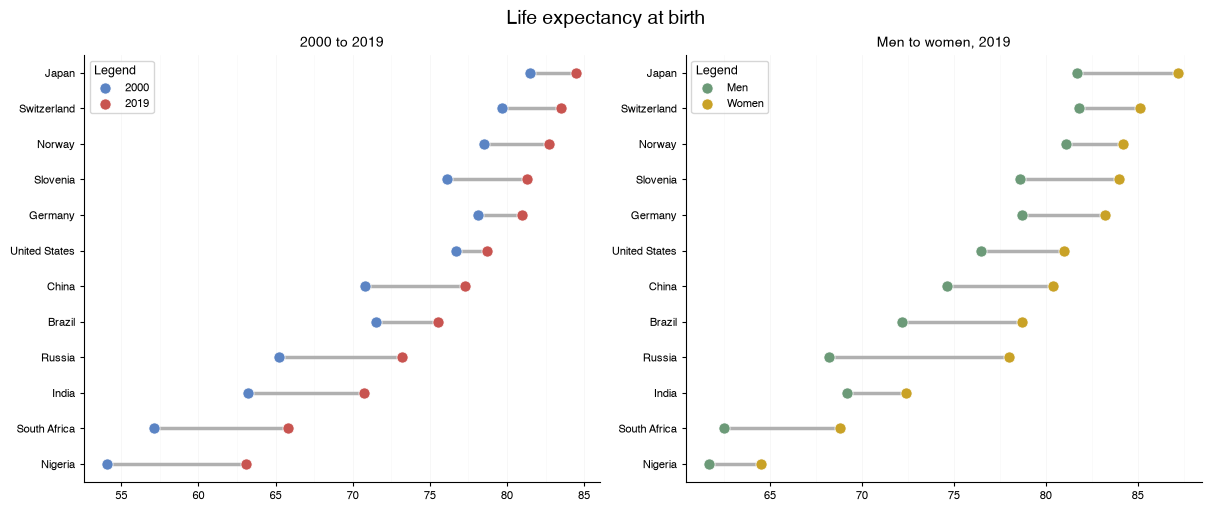

In [25]:
from datachart.utils import Grid

change = DumbbellChart(
    data=life,
    title="2000 to 2019",
    start_name="2000",
    end_name="2019",
)
gap = DumbbellChart(
    data=[{"label": w["label"], "start": m["end"], "end": w["end"]} for w, m in zip(women, men)],
    title="Men to women, 2019",
    start_name="Men",
    end_name="Women",
    style={"plot_dumbbell_start_color": "#6C9A78", "plot_dumbbell_end_color": "#C9A227"},
)

Grid([[change, gap]], title="Life expectancy at birth", figsize=(12, 5)).show()

### Themes

A theme sets the endpoint pair, the connector, the fonts, and the dot edges of every chart at once. See the [Theme Gallery](../../styling/theme-gallery.ipynb) for the whole suite under each theme. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [config](../../styling/config.ipynb).

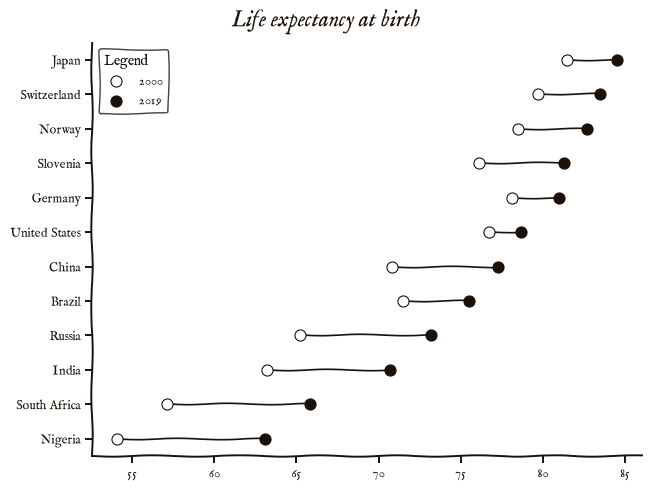

In [26]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.QUILL)
figure = DumbbellChart(data=life, title="Life expectancy at birth", start_name="2000", end_name="2019")
config.set_theme(THEME.DEFAULT)
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [27]:
from datachart.utils import save_figure

figure = DumbbellChart(data=life, title="Life expectancy at birth")
save_figure(figure, "./fig_dumbbell_chart.png", dpi=300)

['./fig_dumbbell_chart.png']

## Real-World Examples

### The gender gap in life expectancy

A dumbbell also shows a range. Here each country runs from men's to women's life expectancy in 2019, sorted by the width of the gap: women outlive men in every country, by under three years in Nigeria and by almost ten in Russia. The highlighted rows are the gaps above six years.

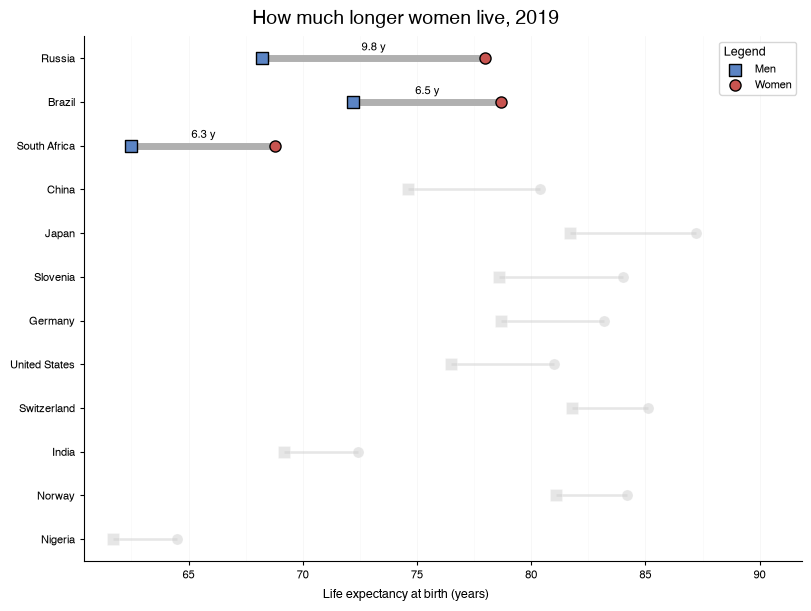

In [28]:
gap_2019 = [
    {"label": w["label"], "start": m["end"], "end": w["end"]}
    for w, m in zip(women, men)
]

DumbbellChart(
    data=gap_2019,
    title="How much longer women live, 2019",
    xlabel="Life expectancy at birth (years)",
    start_name="Men",
    end_name="Women",
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
    show_values=DUMBBELL_VALUE.DELTA,
    value_format="{:.1f} y",
    emphasis_rule={"above": 6},
    marker=(LINE_MARKER.SQUARE, LINE_MARKER.CIRCLE),
    figsize=(8, 6),
).show()